In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

1. Chia tách dữ liệu & Tối ưu hóa mô hình (sklearn.model_selection):

train_test_split: Dùng để chia tập dữ liệu thành các phần riêng biệt (ví dụ: tập huấn luyện train và tập kiểm thử test).

RandomizedSearchCV: Công cụ tự động tìm kiếm các siêu tham số (hyperparameters) tốt nhất cho mô hình bằng cách lấy mẫu ngẫu nhiên, giúp mô hình đạt độ chính xác cao hơn mà không cần thử thủ công từng cấu hình.

2. Tiền xử lý dữ liệu (sklearn.preprocessing):

LabelEncoder: Dùng để chuyển đổi các cột dữ liệu dạng chữ (categorical, ví dụ như phân loại sản phẩm, khu vực) thành các con số nguyên để mô hình máy học có thể hiểu và tính toán được.

3. Đánh giá hiệu suất mô hình (sklearn.metrics):

mean_absolute_error (MAE): Sai số tuyệt đối trung bình (đo lường mức độ lệch trung bình giữa giá trị dự đoán và thực tế).

mean_squared_error (MSE): Sai số bình phương trung bình (phạt nặng hơn các điểm dự đoán bị lệch lớn).

r2_score (R-squared): Hệ số xác định, đo lường mức độ giải thích của mô hình đối với sự biến thiên của dữ liệu (càng gần 1.0 nghĩa là mô hình càng fit tốt).

4. Mô hình học máy chính (xgboost):

from xgboost import XGBRegressor: Import mô hình cây quyết định tăng cường gradient chuyên dụng cho bài toán hồi quy (Regression) – dự báo các giá trị dạng số liên tục (như dự báo số lượng nhu cầu sản phẩm Demand)

5. Lưu trữ mô hình:

import pickle: Thư viện giúp đóng gói và lưu trữ mô hình đã train (.pkl) cũng như các bộ mã hóa (LabelEncoders) xuống ổ cứng để sau đó bạn có thể load trực tiếp vào ứng dụng Streamlit mà không cần train lại từ đầu.

In [2]:
df = pd.read_csv("preprocessed_demand_forecasting_data.csv")

In [3]:
df

,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [4]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [5]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [6]:
target = "Demand"

In [7]:
X = df[features].copy()

In [8]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [9]:
y = df[target]

In [10]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [11]:
label_encoders = {}

categorical_cols = X.select_dtypes(include="object").columns

label_encoders = {}

Khởi tạo một từ điển trống (empty dictionary). Từ điển này sẽ được dùng để lưu trữ các đối tượng LabelEncoder của từng cột chữ.

💡 Tại sao phải lưu lại? Vì khi bạn làm ứng dụng Streamlit sau này, người dùng nhập vào một giá trị chữ (ví dụ: tên ngành hàng "Electronics"), bạn cần dùng chính xác bộ mã hóa đã học lúc train để dịch nó sang con số tương ứng. Nếu không lưu lại, ứng dụng sẽ không biết cách mã hóa dữ liệu mới do người dùng nhập vào.

In [12]:
categorical_cols

Index(['Category'], dtype='object')

In [13]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

thực hiện mã hóa toàn bộ các cột dữ liệu dạng chữ sang dạng số để mô hình học máy có thể đọc được, đồng thời lưu lại các bộ mã hóa để sử dụng cho ứng dụng Streamlit sau này.

In [14]:
label_encoders

{'Category': LabelEncoder()}

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [17]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1
)

khởi tạo mô hình dự báo XGBoost Regressor với một số cấu hình cơ bản.

reg:squarederror viết tắt của Regression with Squared Error, có nghĩa là bài toán hồi quy sử dụng hàm mất mát là sai số bình phương (MSE). Đây là hàm mặc định và chuẩn xác nhất cho các bài toán dự báo giá trị liên tục như dự báo nhu cầu (Demand).

Khi bạn đặt n_jobs=-1, XGBoost sẽ huy động tất cả các nhân (cores) CPU có sẵn trên máy tính của bạn để chạy song song quá trình huấn luyện, giúp mô hình train nhanh hơn rất nhiều (đặc biệt hữu ích với tập dữ liệu lớn).

In [18]:
param_dict = {
    "n_estimators": [200,300,500],
    "max_depth": [3,4,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1.0],
    "colsample_bytree": [0.7,0.8,1.0],
    "min_child_weight": [1,3,5]
}

"n_estimators": [200, 300, 500]

Số lượng cây quyết định (trees) sẽ được xây dựng tuần tự trong mô hình.

Số lượng lớn hơn giúp mô hình học sâu hơn, nhưng nếu quá cao có thể dẫn đến hiện tượng quá khớp (overfitting).

"max_depth": [3, 4, 6, 8]

Chiều sâu tối đa của mỗi cây quyết định.

Giá trị nhỏ (như 3, 4) giúp chống overfitting (mô hình tổng quát tốt hơn), trong khi giá trị lớn (như 8) giúp mô hình học được các quy luật phức tạp nhưng dễ bị học vẹt trên tập train.

"learning_rate": [0.01, 0.05, 0.1]

Tốc độ học (shrinkage).

Tốc độ học nhỏ (như 0.01) đòi hỏi nhiều cây hơn (n_estimators) nhưng thường cho độ chính xác cao và ổn định hơn so với học nhanh (0.1).

"subsample": [0.7, 0.8, 1.0]

Tỷ lệ mẫu dữ liệu ngẫu nhiên được chọn ra để huấn luyện cho mỗi cây (ví dụ: 0.8 nghĩa là mỗi cây chỉ nhìn thấy 80% dữ liệu gốc).

Giúp tăng tính ngẫu nhiên, chống hiện tượng overfitting.

"colsample_bytree": [0.7, 0.8, 1.0]

Tỷ lệ các đặc trưng (features) ngẫu nhiên được chọn ra để xây dựng mỗi cây.

Tương tự như subsample, cách này ép mô hình không quá phụ thuộc vào một vài đặc trưng mạnh nhất, giúp tăng độ bền vững của mô hình.

"min_child_weight": [1, 3, 5]

Trọng lượng tối thiểu của tổng các mẫu dữ liệu trong một nút lá (leaf node).

Giá trị này giúp kiểm soát việc chia nhánh, ngăn chặn mô hình tạo ra các nhánh quá nhỏ hoặc quá nhạy cảm với nhiễu trong dữ liệu.

In [19]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

n_iter=25: Thử nghiệm 25 tổ hợp siêu tham số ngẫu nhiên khác nhau. Con số này đủ lớn để tìm ra một cấu hình rất tốt mà không mất quá nhiều thời gian chờ đợi như GridSearchCV (thử tất cả các tổ hợp).

scoring="neg_mean_absolute_error": Sử dụng Sai số tuyệt đối trung bình âm (Negative MAE) làm hàm đánh giá. Trong bài toán dự báo nhu cầu, MAE cực kỳ trực quan vì nó cho bạn biết mô hình dự đoán lệch trung bình bao nhiêu sản phẩm (ví dụ: lệch trung bình 5 sản phẩm/sku), giúp dễ diễn giải hơn là sai số bình phương (MSE).

cv=3: Chia chéo dữ liệu thành 3 phần (3-fold cross-validation) để kiểm tra độ ổn định của mô hình. Nếu tập dữ liệu của bạn ở mức vừa phải, cv=3 hoặc cv=5 là lựa chọn hoàn hảo.

In [20]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [21]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [22]:
best_model = random_search.best_estimator_

để trích xuất ra mô hình xuất sắc nhất (best_estimator_) sau khi quá trình RandomizedSearchCV hoàn tất việc chạy thử nghiệm và tìm kiếm trên 25 tổ hợp siêu tham số.

In [23]:
y_pred = best_model.predict(X_test)

In [24]:
mean_squared_error(y_test, y_pred)

1276.351318359375

Sai số bình phương trung bình (Mean Squared Error - MSE) giữa giá trị thực tế (y_test) và giá trị mà mô hình dự đoán (y_pred).

In [25]:
best_model.feature_importances_

array([0.07620323, 0.02028277, 0.01793286, 0.5850723 , 0.02140723,
       0.2791016 ], dtype=float32)

dùng để lấy ra mức độ quan trọng (feature importance) của từng đặc trưng (cột dữ liệu) trong mô hình XGBoost sau khi đã huấn luyện xong.

In [26]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

để tạo một Series trong Pandas giúp xếp hạng mức độ quan trọng của các đặc trưng (features) từ cao đến thấp dựa trên mô hình XGBoost đã huấn luyện.

In [27]:
feature_importance

Promotion             0.585072
Category              0.279102
Price                 0.076203
Competitor Pricing    0.021407
Discount              0.020283
Inventory Level       0.017933
dtype: float32

<Axes: >

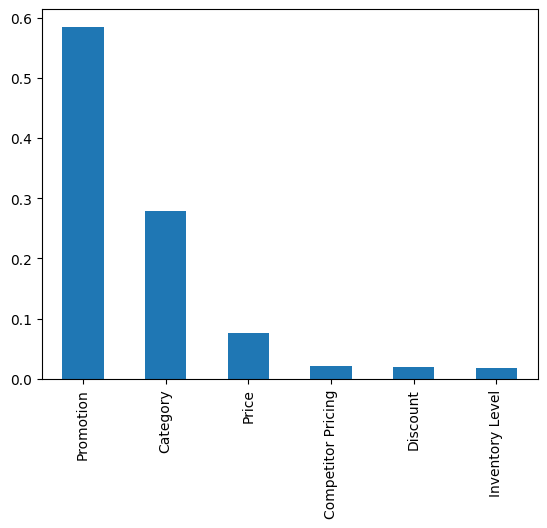

In [28]:
feature_importance.plot(kind="bar")

In [29]:
with open("label_encoders_processData.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [30]:
with open("xgboost_demand_model_processData.pkl", "wb") as f:
    pickle.dump(best_model, f)